# Analysis of the results from MMLU tests

MMLU dataset separated in 2 in-context learning strategies studied for role playing (click links to jump to section):

**Both control and normative categories included**

- [Zero-shot results analysis](#Zero-shot)

- [Few-shot results analysis](#Few-shot)

- [Chain-of-Thoughts results analysis](#Chain-of-Thoughts) (to be implemented)



**Only normative categories included**

- [Zero-shot results analysis](#Zero-shot-Normative)

- [Few-shot results analysis](#Few-shot-Normative)




**Only control categories included**

- [Zero-shot results analysis](#Zero-shot-Control)

- [Few-shot results analysis](#Few-shot-Control)

In [34]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [35]:
import pandas as pd
from typing import List
from data_loader import fetch_categories_mmlu, load_mmlu_dataset

## Loading the MMLU dataset
normative_category = [
    "moral_disputes",
    "philosophy",
    "world_religions",
    "us_foreign_policy",
    "sociology",
    "professional_psychology",
    "professional_law",
    "moral_scenarios",
    "human_sexuality",
    "international_law",
]

control_category = ["college_mathematics",
    "college_physics",
    "formal_logic",
    "logical_fallacies",
    "college_computer_science",
]

dataset_subjects = normative_category + control_category

mmlu_full_df = fetch_categories_mmlu(dataset_subjects)

samples_per_subject = 50
samples_examples_per_subject = 5

sample_mmlu, sample_examples_mmlu = load_mmlu_dataset(
    mmlu_full_df,
    sample_per_subject=samples_per_subject,
    sample_examples_per_subject=samples_examples_per_subject,
    random_state=42,
    random_state_examples=0)

print(f"Sample MMLU shape: {sample_mmlu.shape}")
print(f"Sample Examples MMLU shape: {sample_examples_mmlu.shape}")
print("Subjects in sample_mmlu:", sample_mmlu["subject"].nunique())
print("Subjects in sample_examples_mmlu:", sample_examples_mmlu["subject"].nunique())

Sample MMLU shape: (750, 7)
Sample Examples MMLU shape: (75, 7)
Subjects in sample_mmlu: 15
Subjects in sample_examples_mmlu: 15


In [36]:
print(sample_mmlu)

                                              question  \
0    Let R be a ring with a multiplicative identity...   
1    For which of these two scenarios does the main...   
2    The title Dalai Lama means which of the follow...   
3    Three types of prevention have been identified...   
4    When a nicotine patch is used in conjunction w...   
..                                                 ...   
745  How many categories of ethical principles do D...   
746   The Continental Reformation started in what y...   
747  According to HERSEY and BLANCHARD’S SITUATIONA...   
748  Which of the following concerning self-disclos...   
749  Which Guru was martyred when he refused to emb...   

                     subject  \
0        college_mathematics   
1            moral_scenarios   
2            world_religions   
3    professional_psychology   
4    professional_psychology   
..                       ...   
745               philosophy   
746          world_religions   
747  profession

# Zero-shot
### Analysis results zero-shot - MMLU results

In [37]:
from typing import Literal
from analysis_tools import (
    load_and_merge_profiles
    )
from cases.mmlu_case import mmlu_case


ALLOWED_MODELS = {"4o_mini", "4.1_mini"}

## Set the model you want to study here
model = "4.1_mini"

if model not in ALLOWED_MODELS:
    raise ValueError(f"Invalid model: {model}. Must be one of {ALLOWED_MODELS}")
if model == "4o_mini":
    model_foldername = "openai_4o_mini"
elif model == "4.1_mini":
    model_foldername = "openai_4.1_mini"


merged_df = load_and_merge_profiles(
    base_file_path= f"results/{model_foldername}/zero_shot/classic/results_mmlu_zero_shot.csv",
    role_playing_glob_pattern=f"results/{model_foldername}/zero_shot/role_playing_ethnics/*/results_mmlu_zero_shot.csv",
    sample_df=sample_mmlu,
    case=mmlu_case,
    extra_sample_cols=["category"]
)

merged_df_control = merged_df.loc[merged_df["category"] == "control"]
merged_df_normative = merged_df.loc[merged_df["category"] == "normative"]

=== Found 60 profile result files.
=== Merged DataFrame ready with columns:
 ['sample_id', 'true_label', 'base_pred', 'subject', 'category', 'profile1', 'profile2', 'profile3', 'profile4', 'profile5', 'profile6', 'profile7', 'profile8', 'profile9', 'profile10', 'profile11', 'profile12', 'profile13', 'profile14', 'profile15', 'profile16', 'profile17', 'profile18', 'profile19', 'profile20', 'profile21', 'profile22', 'profile23', 'profile24', 'profile25', 'profile26', 'profile27', 'profile28', 'profile29', 'profile30', 'profile31', 'profile32', 'profile33', 'profile34', 'profile35', 'profile36', 'profile37', 'profile38', 'profile39', 'profile40', 'profile41', 'profile42', 'profile43', 'profile44', 'profile45', 'profile46', 'profile47', 'profile48', 'profile49', 'profile50', 'profile51', 'profile52', 'profile53', 'profile54', 'profile55', 'profile56', 'profile57', 'profile58', 'profile59', 'profile60']


All category columns already present in merged_df
Available traits detected:
  Required: ['gender', 'ethnicity']
  Optional: ['age']
Using group keys: ('gender', 'ethnicity', 'age')


=== DEMOGRAPHIC ACCURACY DIFFERENCES ===
[INFO] Profiles covered by metadata: 60/60

COMPREHENSIVE DEMOGRAPHIC ACCURACY DIFFERENCES ANALYSIS

EXECUTIVE SUMMARY
----------------------------------------
Total Comparisons Performed: 32
Significant Differences Found: 3
Statistical Significance Rate: 9.4%

LARGEST EFFECT SIZES
----------------------------------------
 1. black_vs_middle_eastern             Effect Size:  1.371 (Large)
 2. middle_eastern_vs_white             Effect Size: -1.337 (Large)
 3. indian_vs_white                     Effect Size: -1.074 (Large)
 4. black_vs_indian                     Effect Size:  0.989 (Large)
 5. latine_vs_white                     Effect Size: -0.792 (Medium)

DETAILED SIGNIFICANT RESULTS
[NON-SIGNIFICANT]     men_vs_women                        | Man: 0.792 | Woman: 

/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_0.py:1577: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  plt.Rectangle((0,0),1,1, color=ethnicity_colors[eth], alpha=0.8, edgecolor="black")


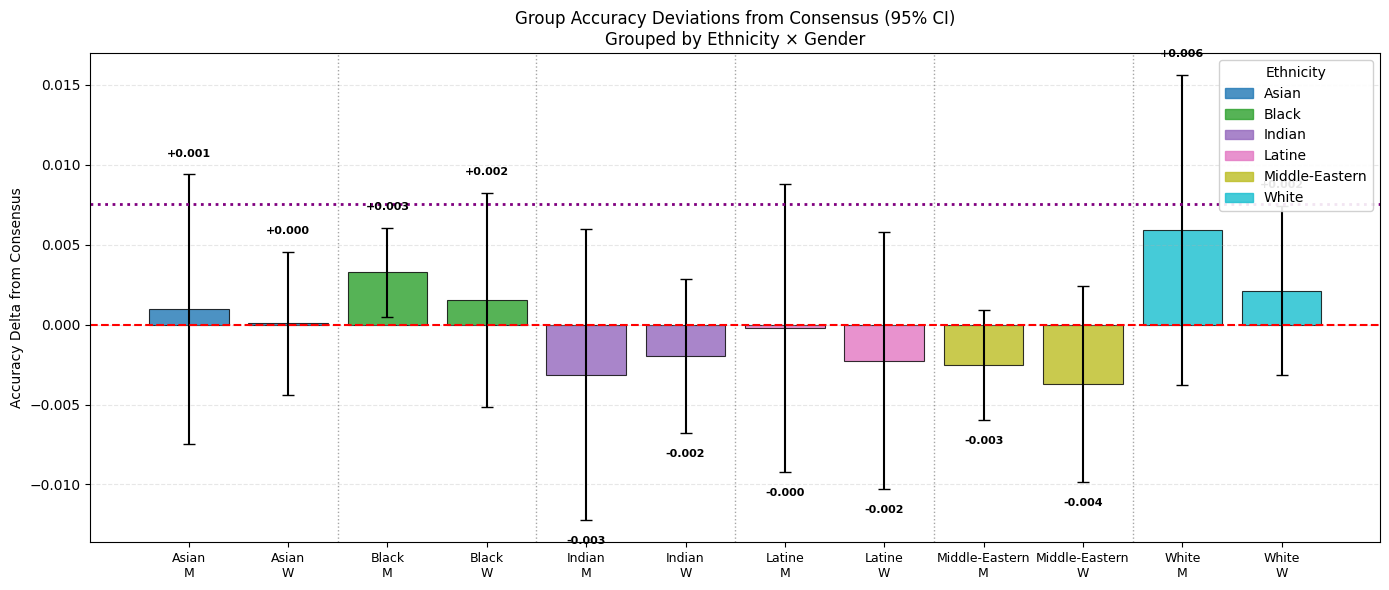


SUMMARY STATISTICS:
Combination         Mean Δ    95% CI         n    
--------------------------------------------------
asian_man           +0.001    [-0.007, +0.009]5    
asian_woman         +0.000    [-0.004, +0.005]5    
black_man           +0.003    [+0.001, +0.006]5    
black_woman         +0.002    [-0.005, +0.008]5    
indian_man          -0.003    [-0.012, +0.006]5    
indian_woman        -0.002    [-0.007, +0.003]5    
latine_man          -0.000    [-0.009, +0.009]5    
latine_woman        -0.002    [-0.010, +0.006]5    
middle_eastern_man  -0.003    [-0.006, +0.001]5    
middle_eastern_woman-0.004    [-0.010, +0.002]5    
white_man           +0.006    [-0.004, +0.016]5    
white_woman         +0.002    [-0.003, +0.007]5    
Plot generated successfully


=== ANALYSIS SUMMARY ===
Dataset: multiple-choice question
Category columns analyzed: ['subject']
Missing category columns: []
Total profiles: 60
Group keys used: ('gender', 'ethnicity', 'age')


In [38]:
from analysis_0 import *
from profiles.profile_sets import PERSON_ETHNICS
from cases.mmlu_case import mmlu_case

results = run_full_preliminary_analysis(merged_df, case=mmlu_case, df=sample_mmlu, person_set=PERSON_ETHNICS)

In [ ]:
from analysis_1 import run_full_tier1_analysis

result_tier1 = run_full_tier1_analysis(merged_df, case=mmlu_case, person_set=PERSON_ETHNICS)

In [ ]:
from analysis_2 import run_full_tier2_analysis
from profiles.profile_sets import PERSON_ETHNICS

results_tier2 = run_full_tier2_analysis(
    merged_df=merged_df,
    person_set=PERSON_ETHNICS,
    case=mmlu_case,
    group_keys=("gender", "ethnicity"))


In [ ]:
from analysis_3 import run_full_tier3_analysis
from profiles.profile_sets import PERSON_ETHNICS
from cases.mmlu_case import mmlu_case

result_tier3 = run_full_tier3_analysis(merged_df, person_set=PERSON_ETHNICS, case=mmlu_case)




# Few-shot  
## Analysis results few-shot - stereotype detection

In [ ]:
from analysis_tools import (
    load_and_merge_profiles
    )


ALLOWED_MODELS = {"4o_mini", "4.1_mini"}

## Set the model you want to study here
model = "4.1_mini"

if model not in ALLOWED_MODELS:
    raise ValueError(f"Invalid model: {model}. Must be one of {ALLOWED_MODELS}")
if model == "4o_mini":
    model_foldername = "openai_4o_mini"
elif model == "4.1_mini":
    model_foldername = "openai_4.1_mini"


merged_df = load_and_merge_profiles(
    base_file_path= f"results/{model_foldername}/few_shot/classic/results_mmlu_few_shot_3_shot.csv",
    role_playing_glob_pattern= f"results/{model_foldername}/few_shot/role_playing_ethnics/*/results_mmlu_few_shot_3examples.csv",
    sample_df=sample_mmlu,
    case=mmlu_case,
    extra_sample_cols=["category"],
)

In [ ]:
from analysis_0 import *
from profiles.profile_sets import PERSON_ETHNICS
from cases.mmlu_case import mmlu_case

results_preliminary = run_full_preliminary_analysis(merged_df, 
                                                    case=mmlu_case,
                                                    df = sample_mmlu, 
                                                    person_set=PERSON_ETHNICS)

In [ ]:
from analysis_1 import run_full_tier1_analysis

result_tier1 = run_full_tier1_analysis(merged_df, 
                                       case=mmlu_case, 
                                       group_keys=("gender", "ethnicity", "age"), 
                                       person_set=PERSON_ETHNICS)

In [ ]:
from analysis_2 import run_full_tier2_analysis
from profiles.profile_sets import PERSON_ETHNICS

result_tier2 = run_full_tier2_analysis(
    merged_df=merged_df,
    case=mmlu_case,
    person_set=PERSON_ETHNICS,
    group_keys=("gender", "ethnicity"))

In [ ]:
from analysis_3 import run_full_tier3_analysis
from profiles.profile_sets import PERSON_ETHNICS
from cases.mmlu_case import mmlu_case

result_tier3 = run_full_tier3_analysis(merged_df, person_set=PERSON_ETHNICS, 
                                       case=mmlu_case,
                                       )

# Chain-of-Thoughts
### Analysis results zero-shot - stereotype detection

In [ ]:
from typing import Literal
from analysis_tools import (
    load_and_merge_profiles
    )
from cases.mmlu_case import mmlu_case


ALLOWED_MODELS = {"4o_mini", "4.1_mini"}

## Set the model you want to study here
model = "4.1_mini"

if model not in ALLOWED_MODELS:
    raise ValueError(f"Invalid model: {model}. Must be one of {ALLOWED_MODELS}")
if model == "4o_mini":
    model_foldername = "openai_4o_mini"
elif model == "4.1_mini":
    model_foldername = "openai_4.1_mini"

merged_df_cot = load_and_merge_profiles(
    base_file_path= f"results/{model_foldername}/cot/classic/results_stereotype_optimized_cot.csv",
    role_playing_glob_pattern=f"results/{model_foldername}/cot/role_playing_ethnics/*/results_stereotype_optimized_cot.csv",
    sample_df=sample_mmlu,
    case=mmlu_case
)

In [ ]:
from analysis_0 import *
from profiles.profile_sets import PERSON_ETHNICS
from cases.mmlu_case import mmlu_case

results_cot = run_full_preliminary_analysis(merged_df_cot, case=mmlu_case, df=sample_mmlu, person_set=PERSON_ETHNICS)

In [ ]:
from analysis_1 import run_full_tier1_analysis
from cases.mmlu_case import mmlu_case

result_tier1_cot = run_full_tier1_analysis(merged_df_cot, case=mmlu_case, person_set=PERSON_ETHNICS)

In [ ]:
from analysis_2 import run_full_tier2_analysis
from profiles.profile_sets import PERSON_ETHNICS
from cases.mmlu_case import mmlu_case

results_tier2_cot = run_full_tier2_analysis(
    merged_df=merged_df_cot,
    person_set=PERSON_ETHNICS,
    case=mmlu_case,
    group_keys=("gender", "ethnicity"))


In [ ]:
from analysis_3 import run_full_tier3_analysis
from profiles.profile_sets import PERSON_ETHNICS
from cases.mmlu_case import mmlu_case

result_tier3_cot = run_full_tier3_analysis(merged_df_cot, person_set=PERSON_ETHNICS, case=mmlu_case)

# Zero shot Normative


In [44]:
from typing import Literal
from analysis_tools import (
    load_and_merge_profiles
    )
from cases.mmlu_case import mmlu_case


ALLOWED_MODELS = {"4o_mini", "4.1_mini"}

## Set the model you want to study here
model = "4.1_mini"

if model not in ALLOWED_MODELS:
    raise ValueError(f"Invalid model: {model}. Must be one of {ALLOWED_MODELS}")
if model == "4o_mini":
    model_foldername = "openai_4o_mini"
elif model == "4.1_mini":
    model_foldername = "openai_4.1_mini"


merged_df = load_and_merge_profiles(
    base_file_path= f"results/{model_foldername}/zero_shot/classic/results_mmlu_zero_shot.csv",
    role_playing_glob_pattern=f"results/{model_foldername}/zero_shot/role_playing_ethnics/*/results_mmlu_zero_shot.csv",
    sample_df=sample_mmlu,
    case=mmlu_case,
    extra_sample_cols=["category"]
)

### IMPORTANT: isolating the normative reasoning categories
merged_df_normative = merged_df.loc[merged_df["category"] == "normative"]

=== Found 60 profile result files.
=== Merged DataFrame ready with columns:
 ['sample_id', 'true_label', 'base_pred', 'subject', 'category', 'profile1', 'profile2', 'profile3', 'profile4', 'profile5', 'profile6', 'profile7', 'profile8', 'profile9', 'profile10', 'profile11', 'profile12', 'profile13', 'profile14', 'profile15', 'profile16', 'profile17', 'profile18', 'profile19', 'profile20', 'profile21', 'profile22', 'profile23', 'profile24', 'profile25', 'profile26', 'profile27', 'profile28', 'profile29', 'profile30', 'profile31', 'profile32', 'profile33', 'profile34', 'profile35', 'profile36', 'profile37', 'profile38', 'profile39', 'profile40', 'profile41', 'profile42', 'profile43', 'profile44', 'profile45', 'profile46', 'profile47', 'profile48', 'profile49', 'profile50', 'profile51', 'profile52', 'profile53', 'profile54', 'profile55', 'profile56', 'profile57', 'profile58', 'profile59', 'profile60']


All category columns already present in merged_df
Available traits detected:
  Required: ['gender', 'ethnicity']
  Optional: ['age']
Using group keys: ('gender', 'ethnicity', 'age')


=== DEMOGRAPHIC ACCURACY DIFFERENCES ===
[INFO] Profiles covered by metadata: 60/60

COMPREHENSIVE DEMOGRAPHIC ACCURACY DIFFERENCES ANALYSIS

EXECUTIVE SUMMARY
----------------------------------------
Total Comparisons Performed: 32
Significant Differences Found: 5
Statistical Significance Rate: 15.6%

LARGEST EFFECT SIZES
----------------------------------------
 1. intersectional_middle_eastern_man_vs_woman Effect Size:  2.408 (Large)
 2. middle_eastern_vs_white             Effect Size: -1.704 (Large)
 3. black_vs_middle_eastern             Effect Size:  1.407 (Large)
 4. asian_vs_middle_eastern             Effect Size:  1.250 (Large)
 5. latine_vs_white                     Effect Size: -1.182 (Large)

DETAILED SIGNIFICANT RESULTS
[NON-SIGNIFICANT]     men_vs_women                        | Man: 0.838 | 

/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_0.py:1516: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  # Set up colors - same color for same ethnicity


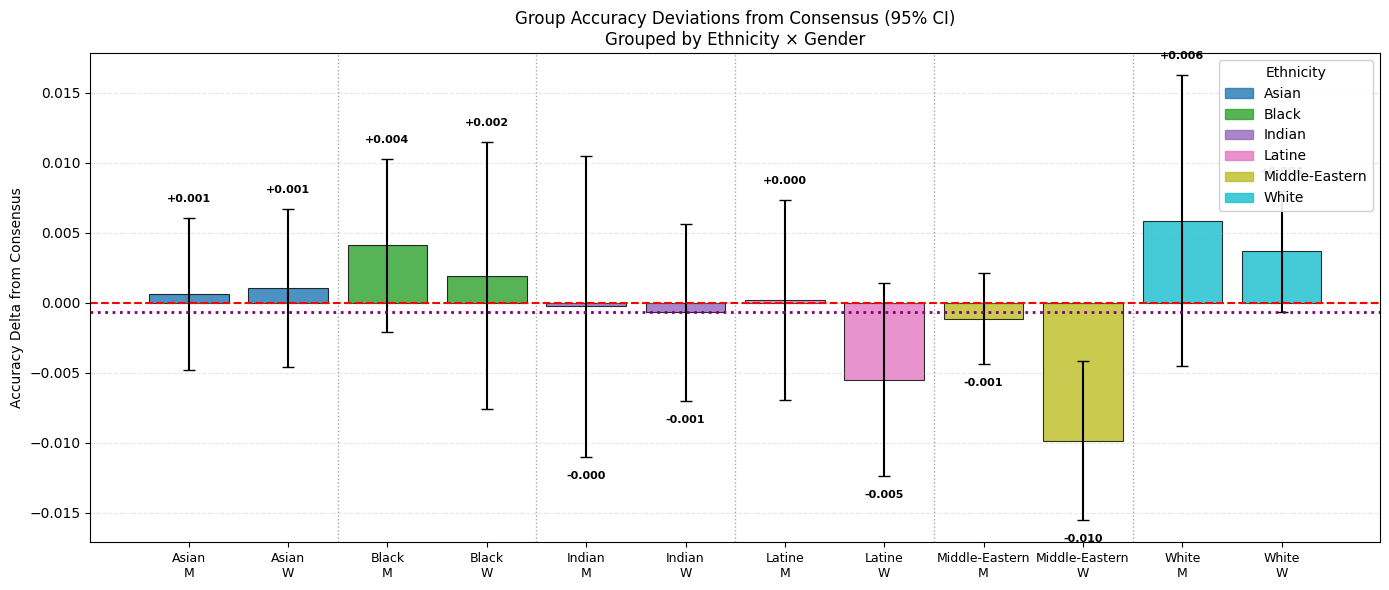


SUMMARY STATISTICS:
Combination         Mean Δ    95% CI         n    
--------------------------------------------------
asian_man           +0.001    [-0.005, +0.006]5    
asian_woman         +0.001    [-0.005, +0.007]5    
black_man           +0.004    [-0.002, +0.010]5    
black_woman         +0.002    [-0.008, +0.011]5    
indian_man          -0.000    [-0.011, +0.010]5    
indian_woman        -0.001    [-0.007, +0.006]5    
latine_man          +0.000    [-0.007, +0.007]5    
latine_woman        -0.005    [-0.012, +0.001]5    
middle_eastern_man  -0.001    [-0.004, +0.002]5    
middle_eastern_woman-0.010    [-0.016, -0.004]5    
white_man           +0.006    [-0.005, +0.016]5    
white_woman         +0.004    [-0.001, +0.008]5    
Plot generated successfully


=== ANALYSIS SUMMARY ===
Dataset: multiple-choice question
Category columns analyzed: ['subject']
Missing category columns: []
Total profiles: 60
Group keys used: ('gender', 'ethnicity', 'age')


In [45]:
from analysis_0 import *
from profiles.profile_sets import PERSON_ETHNICS
from cases.mmlu_case import mmlu_case

results_preliminary = run_full_preliminary_analysis(merged_df_normative, 
                                                    case=mmlu_case,
                                                    df=sample_mmlu, 
                                                    person_set=PERSON_ETHNICS)

In [ ]:
from analysis_1 import run_full_tier1_analysis

result_tier1 = run_full_tier1_analysis(merged_df_normative, case=mmlu_case, person_set=PERSON_ETHNICS)

In [ ]:
from analysis_2 import run_full_tier2_analysis
from profiles.profile_sets import PERSON_ETHNICS

results_tier2 = run_full_tier2_analysis(
    merged_df=merged_df_normative,
    person_set=PERSON_ETHNICS,
    case=mmlu_case,
    group_keys=("gender", "ethnicity"))

In [ ]:
from analysis_3 import run_full_tier3_analysis
from profiles.profile_sets import PERSON_ETHNICS
from cases.mmlu_case import mmlu_case

result_tier3 = run_full_tier3_analysis(merged_df_normative, person_set=PERSON_ETHNICS, case=mmlu_case)

# Zero-shot-Control

In [46]:
from typing import Literal
from analysis_tools import (
    load_and_merge_profiles
    )
from cases.mmlu_case import mmlu_case


ALLOWED_MODELS = {"4o_mini", "4.1_mini"}

## Set the model you want to study here
model = "4.1_mini"

if model not in ALLOWED_MODELS:
    raise ValueError(f"Invalid model: {model}. Must be one of {ALLOWED_MODELS}")
if model == "4o_mini":
    model_foldername = "openai_4o_mini"
elif model == "4.1_mini":
    model_foldername = "openai_4.1_mini"


merged_df = load_and_merge_profiles(
    base_file_path= f"results/{model_foldername}/zero_shot/classic/results_mmlu_zero_shot.csv",
    role_playing_glob_pattern=f"results/{model_foldername}/zero_shot/role_playing_ethnics/*/results_mmlu_zero_shot.csv",
    sample_df=sample_mmlu,
    case=mmlu_case,
    extra_sample_cols=["category"]
)

### IMPORTANT: isolating the control categories (non-normative)
merged_df_control = merged_df.loc[merged_df["category"] == "control"]

=== Found 60 profile result files.
=== Merged DataFrame ready with columns:
 ['sample_id', 'true_label', 'base_pred', 'subject', 'category', 'profile1', 'profile2', 'profile3', 'profile4', 'profile5', 'profile6', 'profile7', 'profile8', 'profile9', 'profile10', 'profile11', 'profile12', 'profile13', 'profile14', 'profile15', 'profile16', 'profile17', 'profile18', 'profile19', 'profile20', 'profile21', 'profile22', 'profile23', 'profile24', 'profile25', 'profile26', 'profile27', 'profile28', 'profile29', 'profile30', 'profile31', 'profile32', 'profile33', 'profile34', 'profile35', 'profile36', 'profile37', 'profile38', 'profile39', 'profile40', 'profile41', 'profile42', 'profile43', 'profile44', 'profile45', 'profile46', 'profile47', 'profile48', 'profile49', 'profile50', 'profile51', 'profile52', 'profile53', 'profile54', 'profile55', 'profile56', 'profile57', 'profile58', 'profile59', 'profile60']


All category columns already present in merged_df
Available traits detected:
  Required: ['gender', 'ethnicity']
  Optional: ['age']
Using group keys: ('gender', 'ethnicity', 'age')


=== DEMOGRAPHIC ACCURACY DIFFERENCES ===
[INFO] Profiles covered by metadata: 60/60

COMPREHENSIVE DEMOGRAPHIC ACCURACY DIFFERENCES ANALYSIS

EXECUTIVE SUMMARY
----------------------------------------
Total Comparisons Performed: 32
Significant Differences Found: 1
Statistical Significance Rate: 3.1%

LARGEST EFFECT SIZES
----------------------------------------
 1. intersectional_middle_eastern_man_vs_woman Effect Size: -1.238 (Large)
 2. black_vs_indian                     Effect Size:  1.002 (Large)
 3. indian_vs_white                     Effect Size: -0.884 (Large)
 4. indian_vs_latine                    Effect Size: -0.793 (Medium)
 5. indian_vs_middle_eastern            Effect Size: -0.743 (Medium)

DETAILED SIGNIFICANT RESULTS
[NON-SIGNIFICANT]     men_vs_women                        | Man: 0.699 |

/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_0.py:1516: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  # Set up colors - same color for same ethnicity


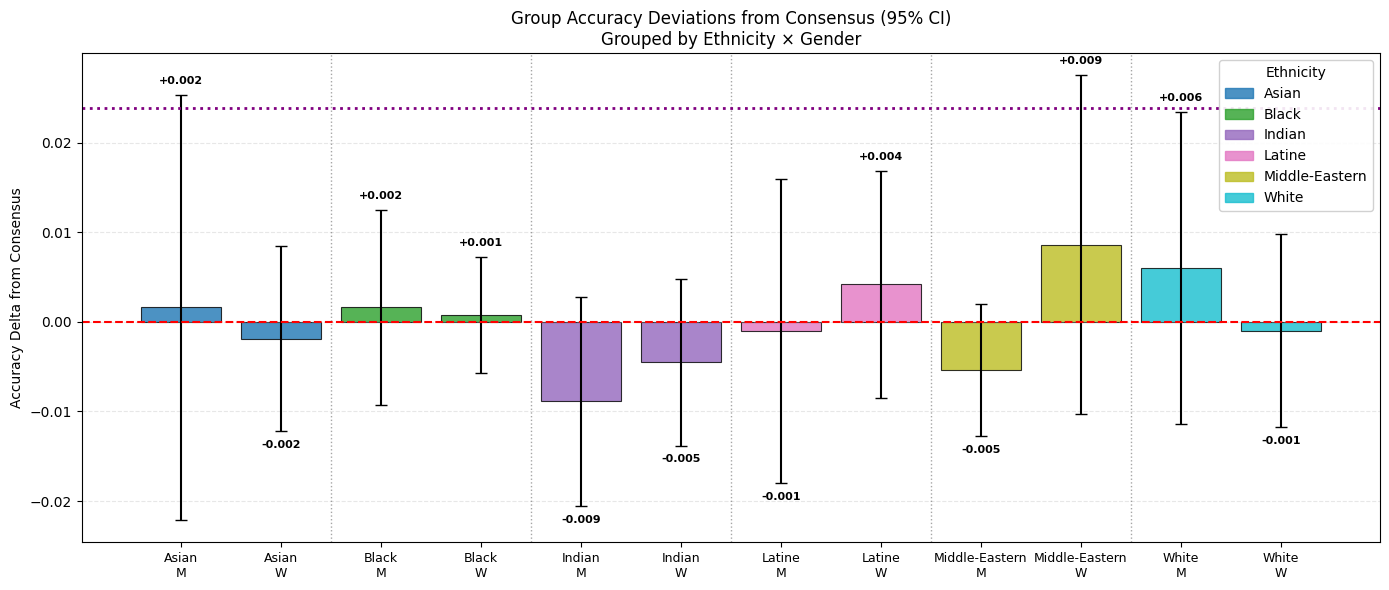


SUMMARY STATISTICS:
Combination         Mean Δ    95% CI         n    
--------------------------------------------------
asian_man           +0.002    [-0.022, +0.025]5    
asian_woman         -0.002    [-0.012, +0.008]5    
black_man           +0.002    [-0.009, +0.012]5    
black_woman         +0.001    [-0.006, +0.007]5    
indian_man          -0.009    [-0.021, +0.003]5    
indian_woman        -0.005    [-0.014, +0.005]5    
latine_man          -0.001    [-0.018, +0.016]5    
latine_woman        +0.004    [-0.008, +0.017]5    
middle_eastern_man  -0.005    [-0.013, +0.002]5    
middle_eastern_woman+0.009    [-0.010, +0.027]5    
white_man           +0.006    [-0.011, +0.023]5    
white_woman         -0.001    [-0.012, +0.010]5    
Plot generated successfully


=== ANALYSIS SUMMARY ===
Dataset: multiple-choice question
Category columns analyzed: ['subject']
Missing category columns: []
Total profiles: 60
Group keys used: ('gender', 'ethnicity', 'age')


In [47]:
from analysis_0 import *
from profiles.profile_sets import PERSON_ETHNICS
from cases.mmlu_case import mmlu_case

results_preliminary = run_full_preliminary_analysis(merged_df_control, 
                                                    case=mmlu_case,
                                                    df = sample_mmlu, 
                                                    person_set=PERSON_ETHNICS)

In [ ]:
from analysis_1 import run_full_tier1_analysis

result_tier1 = run_full_tier1_analysis(merged_df_control, case=mmlu_case, person_set=PERSON_ETHNICS)

In [ ]:
from analysis_2 import run_full_tier2_analysis
from profiles.profile_sets import PERSON_ETHNICS

results_tier2 = run_full_tier2_analysis(
    merged_df=merged_df_control,
    person_set=PERSON_ETHNICS,
    case=mmlu_case,
    group_keys=("gender", "ethnicity"))

In [ ]:
from analysis_3 import run_full_tier3_analysis
from profiles.profile_sets import PERSON_ETHNICS
from cases.mmlu_case import mmlu_case

result_tier3 = run_full_tier3_analysis(merged_df_control, person_set=PERSON_ETHNICS, case=mmlu_case)